# UMAP Analysis

This notebook explores Uniform Manifold Approximation and Projection (UMAP) as a dimensionality reduction technique for the fitness dataset.

UMAP is a non-linear method that reduces high-dimensional data into a lower-dimensional space, usually 2D, while trying to preserve important structure and relationships in the data.

In this project, UMAP is used to explore whether the fitness variables contain patterns or structures that may not be clearly visible with PCA alone.

## Why UMAP?

UMAP is useful because it can capture more complex and non-linear patterns than PCA.

While PCA focuses on variation in a linear way, UMAP focuses more on structure and neighborhood relationships between points.

This makes UMAP especially useful for visualization and pattern discovery in complex datasets.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
import umap

In [7]:
df = pd.read_csv("../data/exercise_dataset.csv")
df.head()

,ID,Exercise,Calories Burn,Dream Weight,Actual Weight,Age,Gender,Duration,Heart Rate,BMI,Weather Conditions,Exercise Intensity
0,1,Exercise 2,286.959851,91.892531,96.301115,45,Male,37,170,29.426275,Rainy,5
1,2,Exercise 7,343.453036,64.165097,61.104668,25,Male,43,142,21.286346,Rainy,5
2,3,Exercise 4,261.223465,70.846224,71.766724,20,Male,20,148,27.899592,Cloudy,4
3,4,Exercise 5,127.183858,79.477008,82.984456,33,Male,39,170,33.729552,Sunny,10
4,5,Exercise 10,416.318374,89.960226,85.643174,29,Female,34,118,23.286113,Cloudy,3


In [2]:
!pip install umap-learn



   ---------------------------------------- 0/2 [pynndescent]
   -------------------- ------------------- 1/2 [umap-learn]
   ---------------------------------------- 2/2 [umap-learn]



In [8]:
# Select numerical variables for UMAP
umap_features = ["Duration", "Heart Rate", "Calories Burn"]

X = df[umap_features].copy().dropna().reset_index(drop=True)

print("Shape of selected data:")
print(X.shape)

display(X.head())

Shape of selected data:
(3864, 3)


,Duration,Heart Rate,Calories Burn
0,37,170,286.959851
1,43,142,343.453036
2,20,148,261.223465
3,39,170,127.183858
4,34,118,416.318374


## Selected Variables

For UMAP, I use the same numerical variables as in the PCA analysis:

- Duration
- Heart Rate
- Calories Burn

This makes it easier to compare the results of PCA and UMAP.

In [9]:
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=umap_features)

print("Standardized data (first 5 rows):")
display(X_scaled_df.head())

Standardized data (first 5 rows):


,Duration,Heart Rate,Calories Burn
0,-0.271241,1.289089,-0.128672
1,0.238771,0.094779,0.359122
2,-1.716274,0.350703,-0.350894
3,-0.101237,1.289089,-1.508268
4,-0.526247,-0.928915,0.988282


## Standardization

Before applying UMAP, the variables are standardized.

This ensures that all variables contribute on a similar scale, which is important when variables have different ranges or units.

## UMAP Step 2: Dimensionality Reduction

UMAP reduces the high-dimensional data into a lower-dimensional space.

In this case, the data is reduced to 2 dimensions (2D) for visualization.

UMAP preserves the structure of the data by keeping nearby points close together.

In [10]:
# Create UMAP model
umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
)

# Apply UMAP
X_umap = umap_model.fit_transform(X_scaled_df)

# Convert to DataFrame
umap_df = pd.DataFrame(X_umap, columns=["UMAP1", "UMAP2"])

print("UMAP output (first 5 rows):")
display(umap_df.head())

c:\Users\mahta\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP output (first 5 rows):


,UMAP1,UMAP2
0,9.144146,4.605028
1,1.745834,7.247542
2,5.667908,2.310993
3,11.091744,4.232823
4,0.284389,3.335514


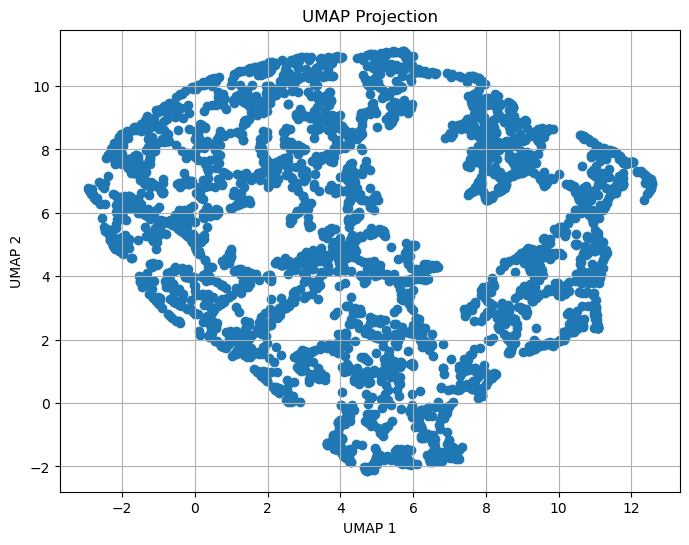

In [11]:
plt.figure(figsize=(8,6))
plt.scatter(umap_df["UMAP1"], umap_df["UMAP2"])

plt.title("UMAP Projection")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.grid(True)

plt.show()

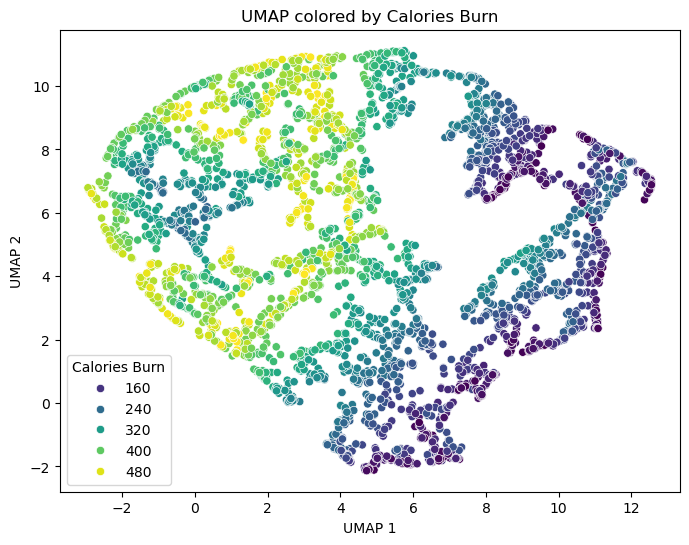

In [12]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=umap_df,
    x="UMAP1",
    y="UMAP2",
    hue=X["Calories Burn"],
    palette="viridis"
)

plt.title("UMAP colored by Calories Burn")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

plt.show()

## Interpretation

The UMAP projection shows how the data is structured in a non-linear space.

Unlike PCA, UMAP can capture more complex patterns and relationships.

If clusters appear, it suggests that the data contains natural groupings.

If the data appears more spread out, it indicates continuous variation rather than distinct groups.

## UMAP Step 3: Hyperparameter Tuning

UMAP results depend strongly on the chosen hyperparameters.

Two important parameters are:

- `n_neighbors`: controls how much local versus global structure is considered
- `min_dist`: controls how tightly points are packed together in the low-dimensional space

In this section, I test different parameter settings to compare how the projection changes.

In [13]:
umap_settings = [
    {"n_neighbors": 5, "min_dist": 0.0, "label": "n_neighbors=5, min_dist=0.0"},
    {"n_neighbors": 15, "min_dist": 0.1, "label": "n_neighbors=15, min_dist=0.1"},
    {"n_neighbors": 50, "min_dist": 0.5, "label": "n_neighbors=50, min_dist=0.5"},
]

umap_results = {}

for setting in umap_settings:
    reducer = umap.UMAP(
        n_neighbors=setting["n_neighbors"],
        min_dist=setting["min_dist"],
        n_components=2,
        random_state=42
    )
    
    embedding = reducer.fit_transform(X_scaled_df)
    umap_results[setting["label"]] = pd.DataFrame(embedding, columns=["UMAP1", "UMAP2"])

c:\Users\mahta\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\mahta\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\mahta\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


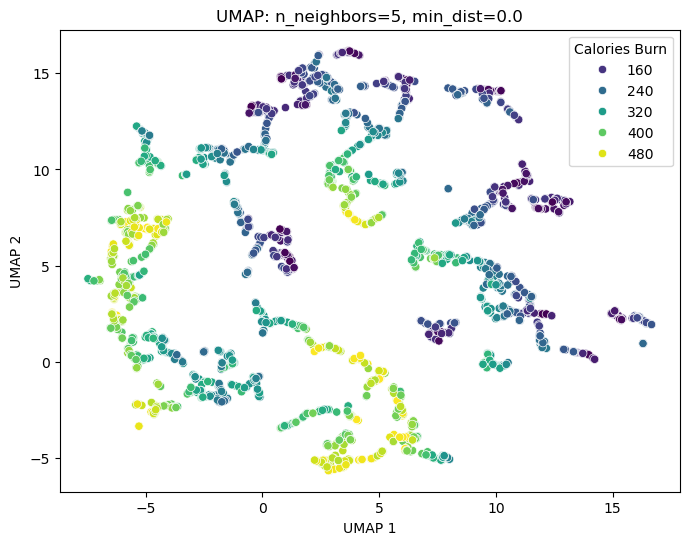

In [14]:
plot_df = umap_results["n_neighbors=5, min_dist=0.0"]

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=plot_df["UMAP1"],
    y=plot_df["UMAP2"],
    hue=X["Calories Burn"],
    palette="viridis"
)
plt.title("UMAP: n_neighbors=5, min_dist=0.0")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()

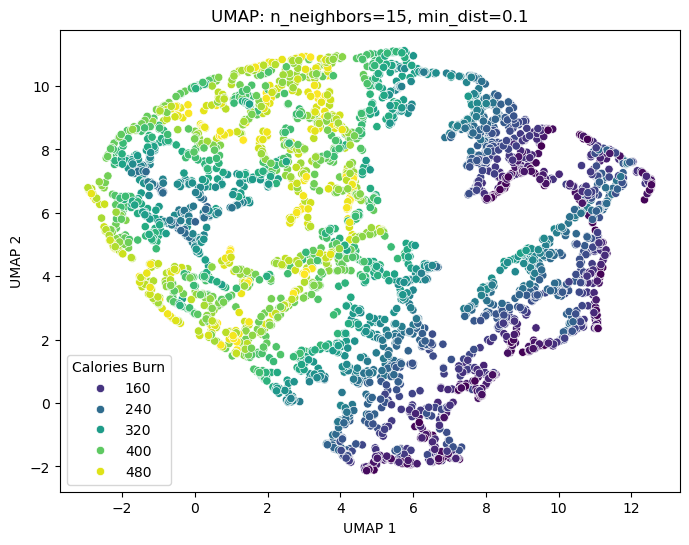

In [15]:
plot_df = umap_results["n_neighbors=15, min_dist=0.1"]

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=plot_df["UMAP1"],
    y=plot_df["UMAP2"],
    hue=X["Calories Burn"],
    palette="viridis"
)
plt.title("UMAP: n_neighbors=15, min_dist=0.1")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()

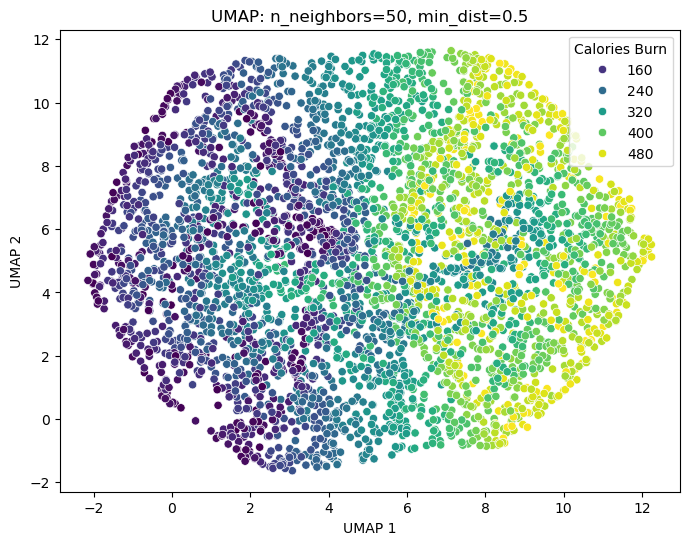

In [16]:
plot_df = umap_results["n_neighbors=50, min_dist=0.5"]

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=plot_df["UMAP1"],
    y=plot_df["UMAP2"],
    hue=X["Calories Burn"],
    palette="viridis"
)
plt.title("UMAP: n_neighbors=50, min_dist=0.5")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()

## Limitations of UMAP

Although UMAP is powerful, it has some limitations:

- Sensitive to hyperparameters: results change depending on settings like n_neighbors and min_dist
- Not always reproducible: results can vary due to random initialization
- Hard to interpret: axes (UMAP1, UMAP2) do not have a clear meaning
- Sensitive to data: outliers and noise can affect the structure

Despite these limitations, UMAP is very effective for visualizing complex patterns in data.

## Comparison: PCA vs UMAP

PCA and UMAP both reduce dimensionality, but in different ways:

- PCA is a linear method that focuses on variance
- UMAP is a non-linear method that focuses on structure and relationships

In this project:
- PCA showed a general structure without clear clusters
- UMAP revealed more complex patterns and a clearer structure

This shows that UMAP can capture patterns that PCA may miss.

## Final Conclusion

In this project, both PCA and UMAP were used to analyze the fitness dataset.

The results showed that:
- There are no clear natural clusters in the data
- The data follows a continuous structure rather than distinct groups
- Calories Burn strongly influences the data structure

UMAP provided a more detailed and structured visualization compared to PCA, revealing patterns that were not clearly visible before.

Overall, combining PCA and UMAP gives a deeper understanding of the dataset.